In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (roc_auc_score, confusion_matrix,
                              RocCurveDisplay, PrecisionRecallDisplay,
                              classification_report)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

# Load data
df = pd.read_csv('../data/processed/final_features.csv')
X = df.drop('stress_label', axis=1).drop(columns=['Credit_Score'])
y = df['stress_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Retrain both models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
    eval_metric='auc', early_stopping_rounds=20,
    random_state=42, verbosity=0
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

print("✅ Models retrained")
print(f"LR AUC:  {roc_auc_score(y_test, lr_probs):.4f}")
print(f"XGB AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

✅ Models retrained
LR AUC:  0.7323
XGB AUC: 0.8219


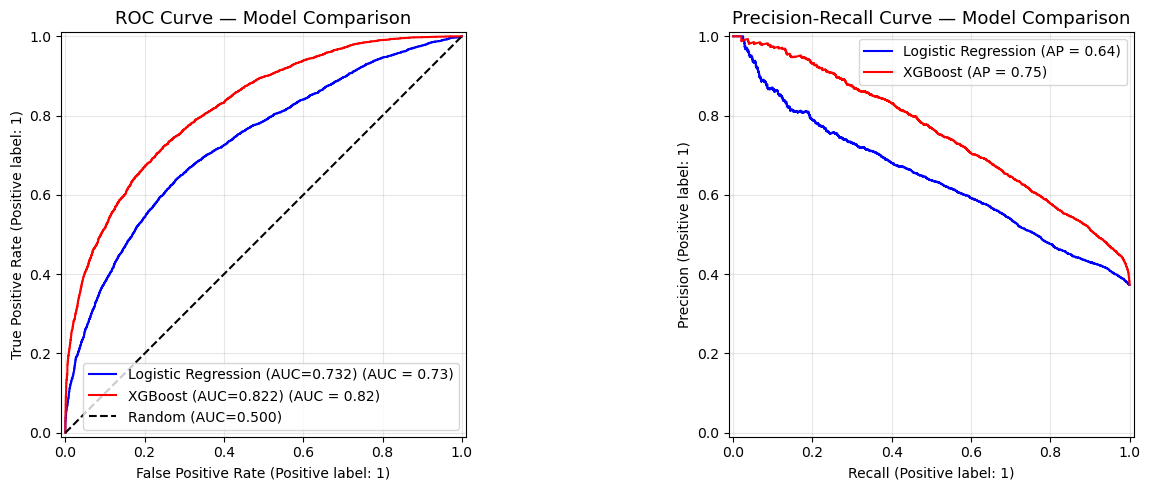

✅ ROC and PR curves saved


In [2]:
# ── PLOT 1: ROC CURVE COMPARISON ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test, lr_probs, name=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_probs):.3f})",
    ax=axes[0], color='blue'
)
RocCurveDisplay.from_predictions(
    y_test, xgb_probs, name=f"XGBoost (AUC={roc_auc_score(y_test, xgb_probs):.3f})",
    ax=axes[0], color='red'
)
axes[0].plot([0,1],[0,1],'k--', label='Random (AUC=0.500)')
axes[0].set_title('ROC Curve — Model Comparison', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(
    y_test, lr_probs, name="Logistic Regression",
    ax=axes[1], color='blue'
)
PrecisionRecallDisplay.from_predictions(
    y_test, xgb_probs, name="XGBoost",
    ax=axes[1], color='red'
)
axes[1].set_title('Precision-Recall Curve — Model Comparison', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC and PR curves saved")


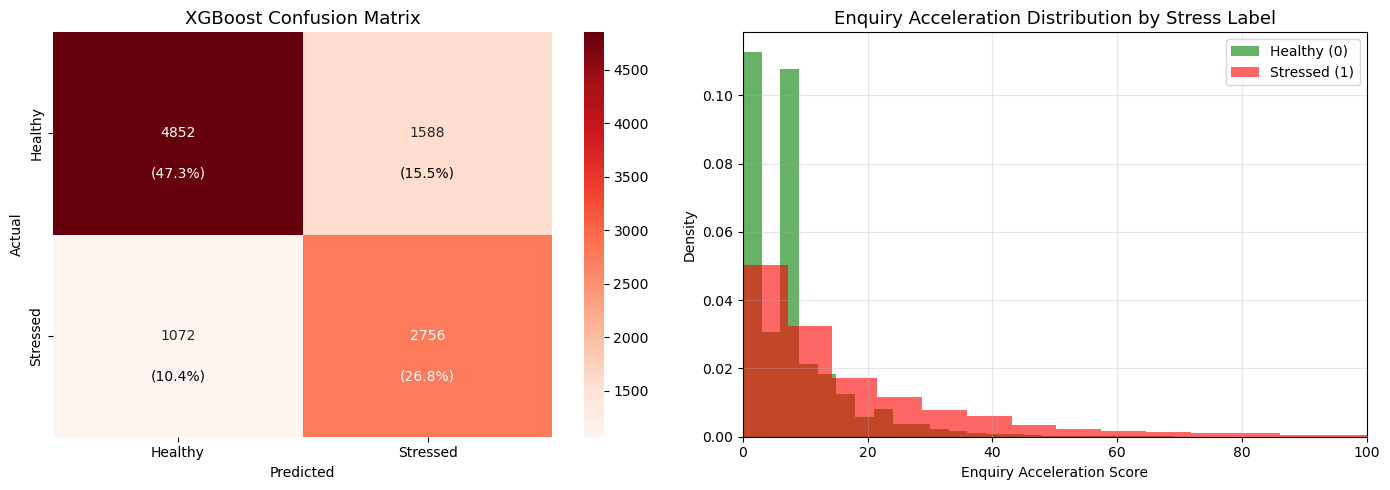

✅ Confusion matrix and distribution plots saved


In [3]:
# ── PLOT 2: CONFUSION MATRIX ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Healthy', 'Stressed'],
            yticklabels=['Healthy', 'Stressed'],
            ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Add percentage annotations
total = cm.sum()
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.7, f'({cm[i,j]/total:.1%})',
                    ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black',
                    fontsize=10)

# Stress distribution by key feature
axes[1].hist(df[df['stress_label']==0]['enquiry_acceleration'],
             bins=50, alpha=0.6, color='green', label='Healthy (0)', density=True)
axes[1].hist(df[df['stress_label']==1]['enquiry_acceleration'],
             bins=50, alpha=0.6, color='red', label='Stressed (1)', density=True)
axes[1].set_title('Enquiry Acceleration Distribution by Stress Label', fontsize=13)
axes[1].set_xlabel('Enquiry Acceleration Score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].set_xlim(0, 100)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix and distribution plots saved")

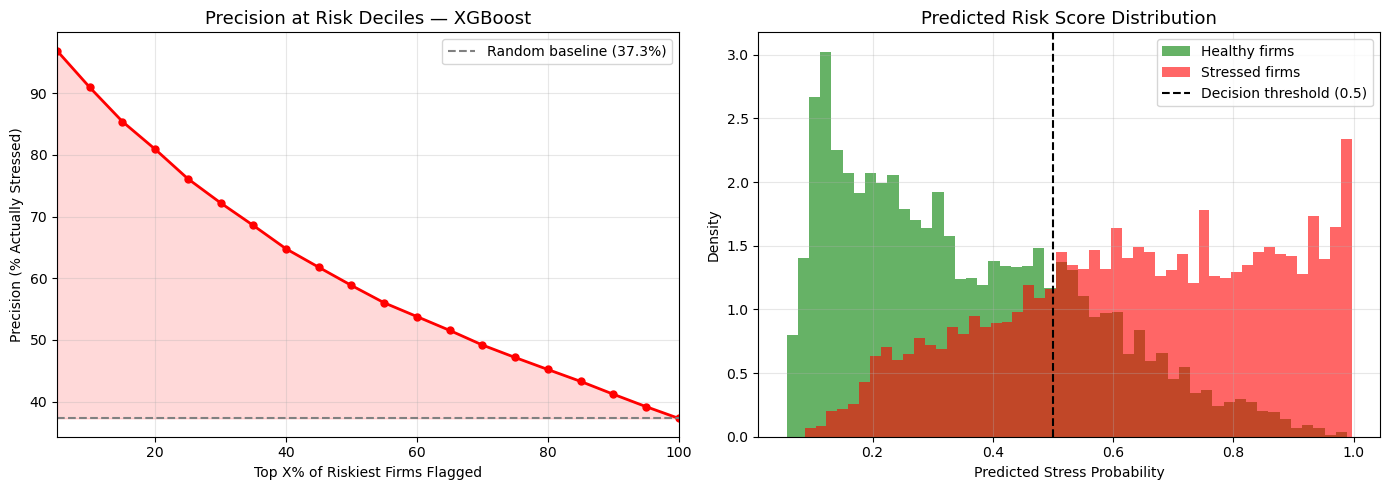

=== PRECISION AT KEY DECILES ===
Top 5%: 96.9% precision
Top 10%: 90.9% precision
Top 15%: 85.4% precision
Top 20%: 80.9% precision
Top 25%: 76.1% precision
Top 30%: 72.2% precision
Top 35%: 68.5% precision
Top 40%: 64.8% precision
Top 45%: 61.8% precision
Top 50%: 58.8% precision
Top 55%: 56.0% precision
Top 60%: 53.8% precision
Top 65%: 51.5% precision
Top 70%: 49.2% precision
Top 75%: 47.1% precision
Top 80%: 45.2% precision
Top 85%: 43.3% precision
Top 90%: 41.2% precision
Top 95%: 39.2% precision
Top 100%: 37.3% precision


In [4]:
# ── PLOT 3: PRECISION AT RISK DECILES ────────────────────────────
# This is the chart that matters most to a lender
# "If I flag the top X% riskiest firms, how accurate am I?"

sorted_idx = np.argsort(xgb_probs)[::-1]
deciles = np.arange(0.05, 1.05, 0.05)
precisions = []

for d in deciles:
    top_n = int(len(y_test) * d)
    precision = y_test.iloc[sorted_idx[:top_n]].mean()
    precisions.append(precision)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision at deciles
axes[0].plot(deciles * 100, [p * 100 for p in precisions],
             marker='o', color='red', linewidth=2, markersize=5)
axes[0].axhline(y=y_test.mean()*100, color='gray', linestyle='--',
                label=f'Random baseline ({y_test.mean():.1%})')
axes[0].fill_between(deciles * 100, [p * 100 for p in precisions],
                      y_test.mean()*100, alpha=0.15, color='red')
axes[0].set_title('Precision at Risk Deciles — XGBoost', fontsize=13)
axes[0].set_xlabel('Top X% of Riskiest Firms Flagged')
axes[0].set_ylabel('Precision (% Actually Stressed)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(5, 100)

# Risk score distribution
axes[1].hist(xgb_probs[y_test==0], bins=50, alpha=0.6,
             color='green', label='Healthy firms', density=True)
axes[1].hist(xgb_probs[y_test==1], bins=50, alpha=0.6,
             color='red', label='Stressed firms', density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
axes[1].set_title('Predicted Risk Score Distribution', fontsize=13)
axes[1].set_xlabel('Predicted Stress Probability')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/precision_deciles_risk_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print key numbers
print("=== PRECISION AT KEY DECILES ===")
for d, p in zip(deciles, precisions):
    print(f"Top {d*100:.0f}%: {p:.1%} precision")

In [5]:
# ── FINAL MODEL SUMMARY TABLE ─────────────────────────────────────
from sklearn.metrics import average_precision_score

lr_auc    = roc_auc_score(y_test, lr_probs)
xgb_auc   = roc_auc_score(y_test, xgb_probs)
lr_ap     = average_precision_score(y_test, lr_probs)
xgb_ap    = average_precision_score(y_test, xgb_probs)

# Precision at top decile for LR
lr_sorted = np.argsort(lr_probs)[::-1]
lr_top10  = y_test.iloc[lr_sorted[:int(len(y_test)*0.1)]].mean()
xgb_top10 = y_test.iloc[np.argsort(xgb_probs)[::-1][:int(len(y_test)*0.1)]].mean()

print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(f"{'Metric':<35} {'Log. Reg':>10} {'XGBoost':>10}")
print("-" * 60)
print(f"{'AUC-ROC':<35} {lr_auc:>10.4f} {xgb_auc:>10.4f}")
print(f"{'Average Precision (AP)':<35} {lr_ap:>10.4f} {xgb_ap:>10.4f}")
print(f"{'Precision @ Top 10%':<35} {lr_top10:>10.1%} {xgb_top10:>10.1%}")
print(f"{'Improvement (AUC)':<35} {'baseline':>10} {xgb_auc-lr_auc:>+10.4f}")
print("=" * 60)
print(f"\nTraining samples: {len(X_train):,}")
print(f"Test samples:     {len(X_test):,}")
print(f"Features used:    {X.shape[1]}")
print(f"Stress rate:      {y.mean():.1%}")
print(f"\n✅ Week 4 complete — all evaluation plots saved to reports/figures/")

FINAL MODEL PERFORMANCE SUMMARY
Metric                                Log. Reg    XGBoost
------------------------------------------------------------
AUC-ROC                                 0.7323     0.8219
Average Precision (AP)                  0.6436     0.7542
Precision @ Top 10%                      78.1%      90.9%
Improvement (AUC)                     baseline    +0.0896

Training samples: 41,068
Test samples:     10,268
Features used:    25
Stress rate:      37.3%

✅ Week 4 complete — all evaluation plots saved to reports/figures/
